# EV Fast-Charging Station Simulation (SimPy)

This notebook simulates a highway rest stop with **6 DC fast chargers**. It compares a baseline fixed-price scenario to a **dynamic pricing** policy that increases prices when queue length exceeds 3 vehicles.

**Outputs:** queue length, utilization, price over time, and summary performance metrics.

## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from ev_charging_model import SimulationParams, run_scenario, to_step_frame

plt.style.use("seaborn-v0_8")

## Run baseline vs dynamic pricing

In [2]:
params = SimulationParams(
    sim_hours=24,
    arrival_rate_per_hour=12,
    base_price=0.40,
    surge_multiplier=0.5,
    price_balk_prob=0.15,
)

baseline = run_scenario(params, dynamic_pricing=False)
dynamic = run_scenario(params, dynamic_pricing=True)

## Summary metrics

In [3]:
metrics_df = pd.DataFrame(
    [baseline["metrics"], dynamic["metrics"]],
    index=["Fixed price", "Dynamic pricing"],
)
metrics_df

,served,balked,avg_queue,max_queue,avg_wait,max_wait,avg_charge,avg_utilization,revenue
Fixed price,259,0,0.009373,2,0.004235,0.11456,0.296482,0.533257,1842.934724
Dynamic pricing,259,0,0.009373,2,0.004235,0.11456,0.296482,0.533257,1842.934724


## Visualize queue length, utilization, and price

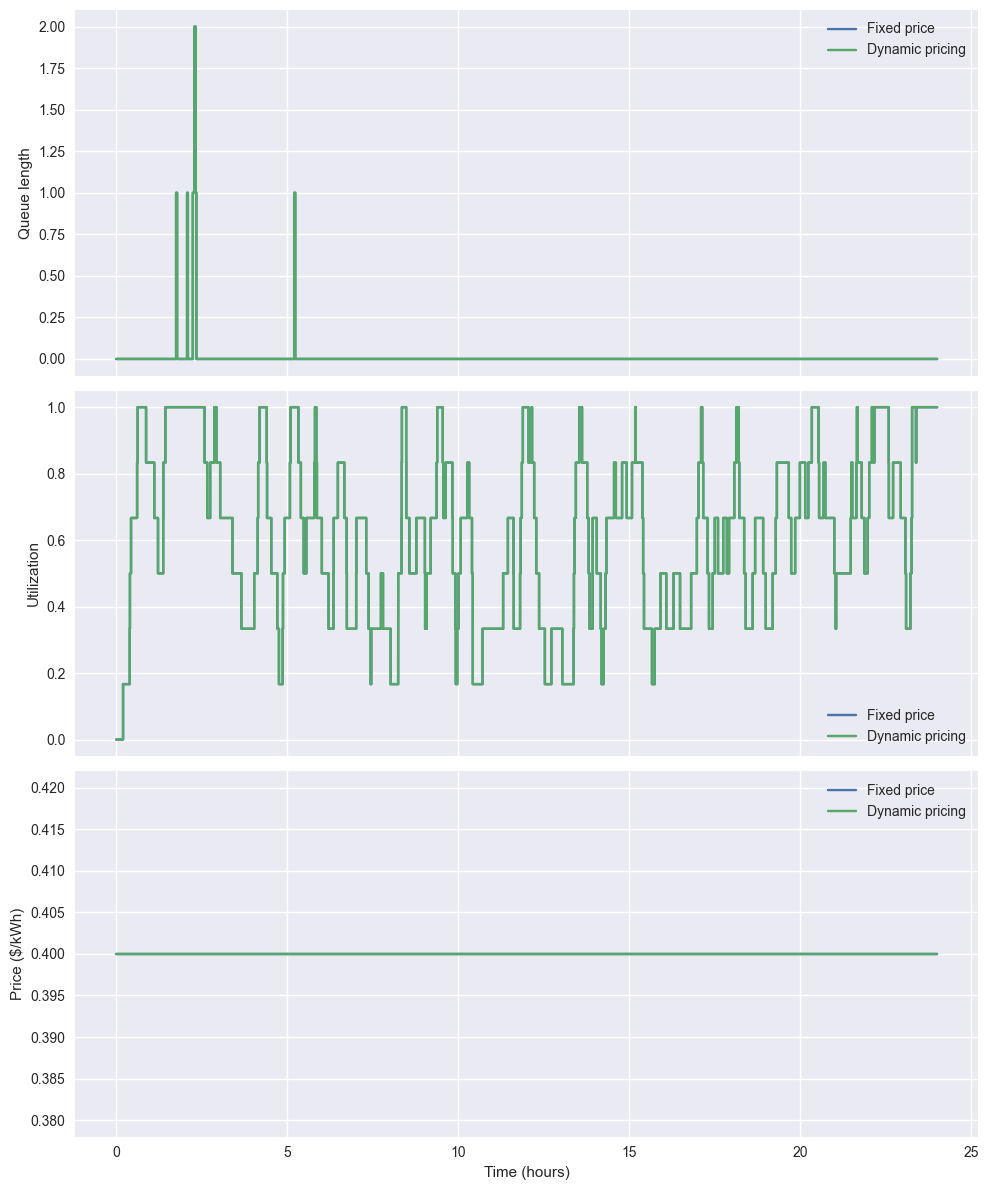

In [4]:
def plot_step(ax, series, sim_hours, label, color=None):
    frame = to_step_frame(series, sim_hours)
    ax.step(frame["time"], frame["value"], where="post", label=label, color=color)

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

plot_step(axes[0], baseline["logs"]["queue"], params.sim_hours, "Fixed price")
plot_step(axes[0], dynamic["logs"]["queue"], params.sim_hours, "Dynamic pricing")
axes[0].set_ylabel("Queue length")
axes[0].legend()

plot_step(axes[1], baseline["logs"]["utilization"], params.sim_hours, "Fixed price")
plot_step(axes[1], dynamic["logs"]["utilization"], params.sim_hours, "Dynamic pricing")
axes[1].set_ylabel("Utilization")
axes[1].legend()

plot_step(axes[2], baseline["logs"]["price"], params.sim_hours, "Fixed price")
plot_step(axes[2], dynamic["logs"]["price"], params.sim_hours, "Dynamic pricing")
axes[2].set_ylabel("Price ($/kWh)")
axes[2].set_xlabel("Time (hours)")
axes[2].legend()

plt.tight_layout()